In [25]:
import h5py
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

In [26]:
def summarize_noise_file(filepath):
    """
    Print a summary of the noise_patterns HDF5 file.
    """
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return

    with h5py.File(filepath, 'r') as f:
        # Access groups
        orig_group = f['original_images']
        bowl_group = f['bowl_images']
        timestamps = f['timestamps'][:]
        frame_numbers = f['frame_numbers'][:]

        print(f"Summary of file: {filepath}")
        print("-" * 40)
        print(f"Total frames saved: {len(frame_numbers)}")
        if len(frame_numbers) > 0:
            print(f"Frame numbers: {frame_numbers[0]} → {frame_numbers[-1]}")
            print(f"Timestamps: {timestamps[0]:.3f} → {timestamps[-1]:.3f}")
        print(f"Original images stored: {len(orig_group)}")
        print(f"Bowl images stored:     {len(bowl_group)}")
        print("Groups in file:", list(f.keys()))

In [27]:
def show_frame(filepath, frame_number):
    """
    Display the original and bowl images for a given frame number
    with timestamp overlay using OpenCV.
    """
    with h5py.File(filepath, 'r') as f:
        timestamps = f['timestamps'][:]
        frame_numbers = f['frame_numbers'][:]

        # Find index of the requested frame
        if frame_number not in frame_numbers:
            print(f"Frame {frame_number} not found in file.")
            return
        idx = np.where(frame_numbers == frame_number)[0][0]
        ts = timestamps[idx]

        frame_name = f'frame_{frame_number:06d}'

        print(frame_name)
        orig_img = f['original_images'][frame_name][:]
        bowl_img = f['bowl_images'][frame_name][:]

        # Overlay timestamp text on the images
        text = f"Frame {frame_number} | Timestamp: {ts:.3f}"
        font = cv2.FONT_HERSHEY_SIMPLEX
        cv2.putText(orig_img, text, (10, 30), font, 0.8, (0, 255, 0), 2)
        cv2.putText(bowl_img, text, (10, 30), font, 0.8, (0, 255, 0), 2)

        # Show the images
        cv2.imshow("Original Image", orig_img)
        cv2.imshow("Bowl Image", bowl_img)

        print(f"Displaying frame {frame_number} at timestamp {ts:.3f}.")
        print("Press any key in the image window to close.")

        cv2.waitKey(0)  # Wait for a key press
        cv2.destroyAllWindows()


In [28]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_timestamp_differences(filepath):
    """
    Load an HDF5 file produced by noise_pattern_writer, compute the time differences
    between consecutive frames, and plot:
      1. Histogram of time differences
      2. Line plot of time difference vs frame index

    Assumes timestamps are stored in nanoseconds (from time.time_ns).
    
    Args:
        filepath (str): Path to the .h5 file
        
    Returns:
        diffs_sec (np.ndarray): Array of time differences between consecutive frames (seconds)
    """
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return None
    
    with h5py.File(filepath, "r") as f:
        # Load all timestamps (in nanoseconds)
        timestamps_ns = f["timestamps"][:]
    
    if len(timestamps_ns) < 2:
        print("Not enough frames to compute differences.")
        return None
    
    # Convert to seconds
    timestamps_sec = timestamps_ns / 1e9
    
    # Compute differences between consecutive timestamps (in seconds)
    diffs_sec = np.diff(timestamps_sec)
    
    # --- Plot 1: Histogram of differences ---
    plt.figure(figsize=(8, 5))
    plt.hist(diffs_sec, bins=30, edgecolor="black")
    plt.xlabel("Time difference between frames (seconds)")
    plt.ylabel("Frequency")
    plt.title("Histogram of Frame-to-Frame Timestamp Differences")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
    
    # --- Plot 2: Line plot of differences over time ---
    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(diffs_sec)+1), diffs_sec, marker='o', linestyle='-', alpha=0.7)
    plt.xlabel("Frame index (difference number)")
    plt.ylabel("Δ Time (seconds)")
    plt.title("Frame-to-Frame Time Differences Over Time")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
    
    return diffs_sec


In [29]:
filename = "noise_patterns_20250829_155805.h5"
filepath = "C:\\Users\\theru\\jrhee\data\\stest_data\\" + filename

with h5py.File(filepath, "r") as f:
        if "original_images" not in f or "bowl_images" not in f:
            raise KeyError("HDF5 must contain 'original_images' and 'bowl_images' groups.")


In [30]:
# Summarize the file
summarize_noise_file(filepath)

Summary of file: C:\Users\theru\jrhee\data\stest_data\noise_patterns_20250829_155805.h5
----------------------------------------
Total frames saved: 45277
Frame numbers: 0 → 45276
Timestamps: 366133357998100.000 → 366733297778500.000
Original images stored: 45277
Bowl images stored:     45277
Groups in file: ['bowl_images', 'frame_numbers', 'original_images', 'timestamps']


In [31]:
show_frame(filepath, frame_number=41)


frame_000041
Displaying frame 41 at timestamp 366133869358900.000.
Press any key in the image window to close.


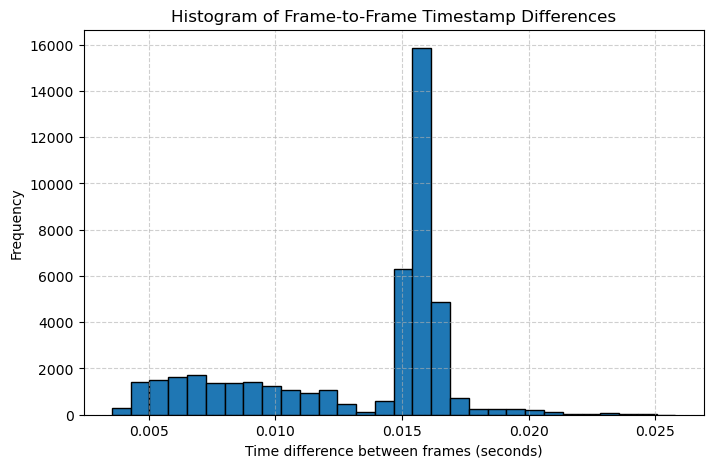

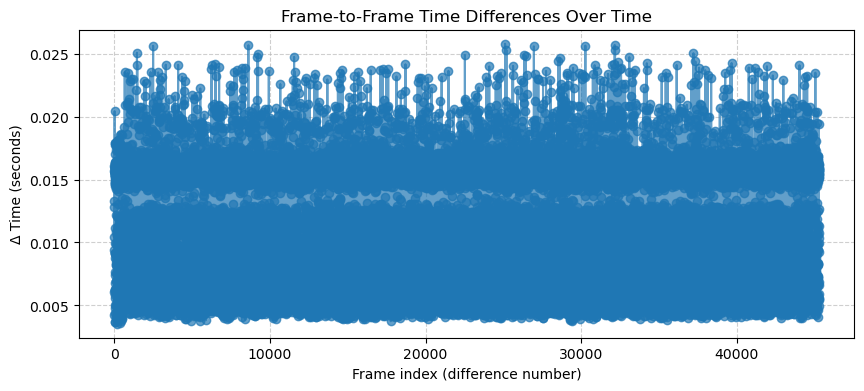

Average frame interval: 0.013250724012722374
Standard deviation: 0.00406448745647407
Approx. FPS: 75.46757437856779


In [32]:
diffs = plot_timestamp_differences(filepath)

if diffs is not None:
    print("Average frame interval:", np.mean(diffs))
    print("Standard deviation:", np.std(diffs))
    print("Approx. FPS:", 1.0 / np.mean(diffs))


In [33]:
def plot_timestamps(filepath):
    """
    Visualize the timestamps of each frame, normalized so that
    the first frame is at 0 seconds.
    
    Args:
        filepath (str): Path to the .h5 file
    """
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    
    with h5py.File(filepath, "r") as f:
        timestamps = f["timestamps"][:]
        frame_numbers = f["frame_numbers"][:]
    
    if len(timestamps) == 0:
        print("No frames found in file.")
        return
    
    # Normalize timestamps (first frame = 0)
    normalized_ts = timestamps - timestamps[0]
    
    # Plot frame number vs normalized timestamp
    plt.figure(figsize=(10, 5))
    plt.plot(frame_numbers, normalized_ts, marker='o', linestyle='-', alpha=0.7)
    plt.xlabel("Frame Number")
    plt.ylabel("Timestamp (seconds, normalized to first frame)")
    plt.title("Timestamps of Frames (First Frame = 0s)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

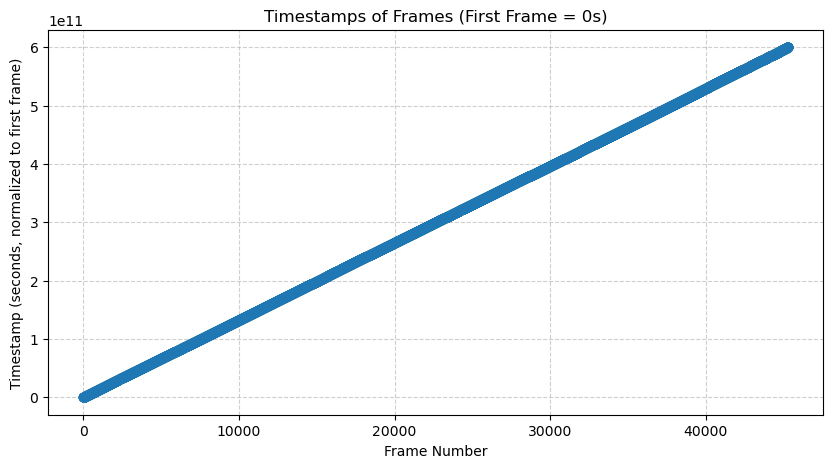

In [34]:
plot_timestamps(filepath)


In [35]:
import h5py
import numpy as np
import os

def find_duplicate_timestamp_frames(filepath):
    """
    Find frames where the difference in timestamps between consecutive frames is 0.
    
    Args:
        filepath (str): Path to the .h5 file
    
    Returns:
        duplicates (list of tuples): List of (frame_number_prev, frame_number_curr, timestamp)
    """
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return []
    
    with h5py.File(filepath, "r") as f:
        timestamps = f["timestamps"][:]
        frame_numbers = f["frame_numbers"][:]
    
    if len(timestamps) < 2:
        print("Not enough frames to check for duplicates.")
        return []
    
    # Find where timestamp difference is zero
    diffs = np.diff(timestamps)
    zero_idx = np.where(diffs == 0)[0]
    
    duplicates = []
    for idx in zero_idx:
        duplicates.append((int(frame_numbers[idx]), int(frame_numbers[idx+1]), float(timestamps[idx])))
    
    if duplicates:
        print("Frames with duplicate timestamps found:")
        for prev_f, curr_f, ts in duplicates:
            print(f"  Frame {prev_f} and Frame {curr_f} → Timestamp = {ts}")
    else:
        print("No duplicate timestamps found.")
    
    return duplicates


In [36]:
duplicates = find_duplicate_timestamp_frames(filepath)

if duplicates:
    print(f"Total duplicates: {len(duplicates)}")
else:
    print("All timestamps are unique.")

No duplicate timestamps found.
All timestamps are unique.
